In [ ]:
!pip -q install pypdf langchain langchain-community langchain-text-splitters
!pip -q install sentence-transformers faiss-cpu rank-bm25
!pip -q install transformers accelerate torch


In [ ]:
import re
import time
import numpy as np
from typing import List, Tuple

from pypdf import PdfReader
from rank_bm25 import BM25Okapi

from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings

from transformers import pipeline
from sentence_transformers import CrossEncoder

In [ ]:
from google.colab import files

uploaded = files.upload()

pdf_paths = []
for file_name in uploaded.keys():
    if file_name.lower().endswith(".pdf"):
        pdf_paths.append(file_name)

print("✅ Uploaded PDFs:", pdf_paths)


Saving MACHINE LEARNING(R17A0534).pdf to MACHINE LEARNING(R17A0534).pdf
✅ Uploaded PDFs: ['MACHINE LEARNING(R17A0534).pdf']


In [ ]:
def clean_text(text: str) -> str:
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def load_pdfs_as_documents(pdf_paths: List[str]) -> List[Document]:
    all_docs = []

    for pdf in pdf_paths:
        reader = PdfReader(pdf)

        for page_no, page in enumerate(reader.pages):
            text = page.extract_text()
            if text and text.strip():
                all_docs.append(
                    Document(
                        page_content=clean_text(text),
                        metadata={
                            "source_file": pdf,
                            "page": page_no + 1
                        }
                    )
                )

    return all_docs


docs = load_pdfs_as_documents(pdf_paths)
print("✅ Total PDF Pages Loaded:", len(docs))


✅ Total PDF Pages Loaded: 120


In [ ]:
def chunk_documents(docs, chunk_size=900, chunk_overlap=200):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ".", " ", ""]
    )
    chunks = splitter.split_documents(docs)
    return chunks


chunks = chunk_documents(docs)
print("✅ Total Chunks Created:", len(chunks))


✅ Total Chunks Created: 366


In [ ]:
def route_query(user_query: str) -> str:
    """
    Returns:
    - "bm25"   -> keyword-heavy query (page, definition, exact terms)
    - "vector" -> semantic query (why/how/difference)
    - "hybrid" -> default
    - "summary"-> summary mode
    """
    q = user_query.lower().strip()

    if any(word in q for word in ["summarize", "summary", "overview", "brief", "in short"]):
        return "summary"

    keyword_patterns = [
        r"\bpage\b",
        r"\bsection\b",
        r"\bchapter\b",
        r"\btable\b",
        r"\bfigure\b",
        r"\baccording to\b",
        r"\bdefinition\b",
        r"\byear\b",
        r"\bdate\b",
        r"\bformula\b",
        r"\bexact\b",
        r"\bwhat is\b"
    ]

    if any(re.search(p, q) for p in keyword_patterns):
        return "bm25"

    if any(word in q for word in ["why", "how", "difference", "compare", "advantages", "disadvantages"]):
        return "vector"

    return "hybrid"


In [ ]:
# ✅ Embeddings
embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# ✅ Vector store
vectorstore = FAISS.from_documents(chunks, embedding_model)

# ✅ BM25
tokenized_corpus = [c.page_content.lower().split() for c in chunks]
bm25 = BM25Okapi(tokenized_corpus)

print("✅ Hybrid Retriever Ready!")


✅ Hybrid Retriever Ready!


In [ ]:
def bm25_search(query: str, k=10):
    tokenized_query = query.lower().split()
    scores = bm25.get_scores(tokenized_query)

    ranked = sorted(list(enumerate(scores)), key=lambda x: x[1], reverse=True)
    top_idx = [i for i, _ in ranked[:k]]

    return [chunks[i] for i in top_idx]


def vector_search(query: str, k=10):
    return vectorstore.similarity_search(query, k=k)


def hybrid_search(query: str, k=15):
    bm_docs = bm25_search(query, k=k)
    vec_docs = vector_search(query, k=k)

    merged = []
    seen = set()

    for d in bm_docs + vec_docs:
        key = (d.metadata.get("source_file"), d.metadata.get("page"), d.page_content[:70])
        if key not in seen:
            merged.append(d)
            seen.add(key)

    return merged


In [ ]:
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
print("✅ Re-Ranker Loaded!")


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

✅ Re-Ranker Loaded!


In [ ]:
def rerank_docs(query: str, docs: List[Document], top_k=6):
    pairs = [(query, d.page_content) for d in docs]
    scores = reranker.predict(pairs)

    scored_docs = list(zip(docs, scores))
    scored_docs.sort(key=lambda x: x[1], reverse=True)

    top_docs = [d for d, s in scored_docs[:top_k]]
    top_scores = [float(s) for d, s in scored_docs[:top_k]]

    return top_docs, top_scores


In [ ]:
llm = pipeline(
    "text2text-generation",
    model="google/flan-t5-base",
    max_new_tokens=280
)

print("✅ LLM Loaded!")


Device set to use cpu


✅ LLM Loaded!


In [ ]:
verifier_llm = pipeline(
    "text2text-generation",
    model="google/flan-t5-base",
    max_new_tokens=160
)

def verify_answer(query: str, answer: str, context: str):
    prompt = f"""
You are an answer verifier.

Check if the ANSWER is fully supported by CONTEXT.

Return ONLY one of these:
- VERIFIED ✅
- NOT VERIFIED ❌

QUESTION: {query}
ANSWER: {answer}

CONTEXT:
{context}

Result:
"""
    out = verifier_llm(prompt)[0]["generated_text"].strip()
    return out


Device set to use cpu


In [ ]:
def format_citations(docs: List[Document]):
    citations = []
    for d in docs:
        citations.append(f"📄 {d.metadata.get('source_file')} | Page {d.metadata.get('page')}")
    return list(dict.fromkeys(citations))


def build_context(docs: List[Document], max_chars=5000):
    context = ""
    for d in docs:
        chunk = d.page_content
        if len(context) + len(chunk) < max_chars:
            context += chunk + "\n\n"
        else:
            break
    return context.strip()


def extraordinary_rag(query: str,
                      initial_k=15,
                      rerank_top_k=6,
                      show_debug=True):

    start = time.time()

    # 1) Route query
    mode = route_query(query)

    # 2) Retrieve docs
    if mode == "bm25":
        retrieved = bm25_search(query, k=initial_k)
    elif mode == "vector":
        retrieved = vector_search(query, k=initial_k)
    elif mode == "summary":
        retrieved = hybrid_search(query, k=initial_k)
    else:
        retrieved = hybrid_search(query, k=initial_k)

    # 3) Re-rank docs (Cross Encoder)
    reranked_docs, rerank_scores = rerank_docs(query, retrieved, top_k=rerank_top_k)

    # 4) Build context
    context = build_context(reranked_docs)

    # 5) Generate Answer
    prompt = f"""
You are a professional PDF assistant.

RULES:
1) Answer ONLY using the context.
2) If not found, say: "I cannot find this in the document."
3) Keep answer clean and direct.

CONTEXT:
{context}

QUESTION:
{query}

ANSWER:
"""
    answer = llm(prompt)[0]["generated_text"]

    # 6) Verify Answer
    verdict = verify_answer(query, answer, context)

    # 7) Confidence Score (simple)
    confidence = float(np.mean(rerank_scores)) if len(rerank_scores) > 0 else 0.0

    end = time.time()

    # 8) Print output
    print("\n" + "="*90)
    print(f"🧠 QUESTION: {query}")
    print(f"⚡ ROUTER MODE: {mode.upper()}")
    print(f"✅ ANSWER:\n{answer}")
    print("-"*90)
    print(f"🛡️ VERIFICATION: {verdict}")
    print(f"📈 CONFIDENCE SCORE (avg rerank): {confidence:.4f}")
    print(f"⏱️ TIME: {end-start:.2f} sec")
    print("-"*90)

    print("📌 CITATIONS (Top Evidence):")
    for c in format_citations(reranked_docs):
        print("  ", c)

    if show_debug:
        print("-"*90)
        print("🔍 TOP RERANK SCORES:")
        for i, s in enumerate(rerank_scores):
            print(f"  Rank {i+1}: {s:.4f}")

    print("="*90 + "\n")

    return answer, verdict, confidence, reranked_docs


In [ ]:
extraordinary_rag("What is Baldwin Effect")


Token indices sequence length is longer than the specified maximum sequence length for this model (1083 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (1217 > 512). Running this sequence through the model will result in indexing errors



🧠 QUESTION: What is Baldwin Effect
⚡ ROUTER MODE: BM25
✅ ANSWER:
The Baldwin effect is based on the following observations:  If a species is evolving in a changing environment, there will be evolutionary pressure to favor individuals with the capability to learn during their lifetime. For example, if a new predator appears in the environment, then individuals capable of learning to avoid the predator will be more successful than individuals who cannot learn. In effect, the ability to learn allows an individual to perform a small local search during its lifetime to maximize its fitness. In contrast, nonlearning individuals whose f itness is fully determined by their genetic makeup will operate at a relative disadvantage.
------------------------------------------------------------------------------------------
🛡️ VERIFICATION: VERIFIED
📈 CONFIDENCE SCORE (avg rerank): 1.8827
⏱️ TIME: 72.06 sec
------------------------------------------------------------------------------------------
📌 

('The Baldwin effect is based on the following observations:  If a species is evolving in a changing environment, there will be evolutionary pressure to favor individuals with the capability to learn during their lifetime. For example, if a new predator appears in the environment, then individuals capable of learning to avoid the predator will be more successful than individuals who cannot learn. In effect, the ability to learn allows an individual to perform a small local search during its lifetime to maximize its fitness. In contrast, nonlearning individuals whose f itness is fully determined by their genetic makeup will operate at a relative disadvantage.',
 'VERIFIED',
 1.8826868335405986,
 [Document(metadata={'source_file': 'MACHINE LEARNING(R17A0534).pdf', 'page': 119}, page_content='. One such mechanism is called the Baldwin effect, after J. M. Baldwin (1896), who first suggested the idea. The Baldwin effect is based on the following observations: \uf0b7 If a species is evolving

In [ ]:
chat_memory = []   # list of {"role": "user"/"assistant", "content": "..."}


In [ ]:
def add_to_memory(role: str, content: str, max_turns=8):
    """
    Stores messages in memory.
    max_turns means maximum last turns (user+assistant) to keep.
    """
    chat_memory.append({"role": role, "content": content})

    # keep only last max_turns*2 messages (user + assistant)
    if len(chat_memory) > max_turns * 2:
        del chat_memory[:len(chat_memory) - max_turns * 2]


def memory_as_text():
    """
    Converts memory into dialogue format for prompt.
    """
    text = ""
    for m in chat_memory:
        if m["role"] == "user":
            text += f"User: {m['content']}\n"
        else:
            text += f"Assistant: {m['content']}\n"
    return text.strip()


In [ ]:
def dashboard_report(query, mode, retrieved_docs, reranked_docs, rerank_scores, verdict, confidence, total_time):
    print("\n" + "="*110)
    print("📊 EXTRAORDINARY RAG DASHBOARD")
    print("="*110)

    print(f"🧠 QUERY           : {query}")
    print(f"⚡ ROUTER MODE      : {mode.upper()}")
    print(f"📚 CHUNKS RETRIEVED : {len(retrieved_docs)} (before rerank)")
    print(f"🏆 FINAL TOP CHUNKS : {len(reranked_docs)} (after rerank)")
    print(f"🛡️ VERIFIED         : {verdict}")
    print(f"📈 CONFIDENCE SCORE : {confidence:.4f}")
    print(f"⏱️ TIME TAKEN       : {total_time:.2f} sec")
    print("-"*110)

    print("📌 FINAL SOURCES / CITATIONS:")
    for d in reranked_docs:
        src = d.metadata.get("source_file", "unknown")
        page = d.metadata.get("page", "NA")
        print(f"   ✅ {src} | Page {page}")

    print("-"*110)
    print("🔍 TOP RERANK SCORES + CHUNK PREVIEW (first 250 chars):")
    for i, (doc, score) in enumerate(zip(reranked_docs, rerank_scores), start=1):
        preview = doc.page_content[:250].replace("\n", " ")
        src = doc.metadata.get("source_file", "unknown")
        page = doc.metadata.get("page", "NA")
        print(f"\n🏅 Rank {i} | Score: {score:.4f} | {src} (Page {page})")
        print(f"   Preview: {preview}...")

    print("="*110 + "\n")


In [ ]:
def extraordinary_rag_v2(query: str,
                         initial_k=20,
                         rerank_top_k=6,
                         memory_turns=6,
                         show_dashboard=True):

    start = time.time()

    # 1) ROUTER MODE
    mode = route_query(query)

    # 2) RETRIEVE
    if mode == "bm25":
        retrieved = bm25_search(query, k=initial_k)
    elif mode == "vector":
        retrieved = vector_search(query, k=initial_k)
    elif mode == "summary":
        retrieved = hybrid_search(query, k=initial_k)
    else:
        retrieved = hybrid_search(query, k=initial_k)

    # 3) RERANK
    reranked_docs, rerank_scores = rerank_docs(query, retrieved, top_k=rerank_top_k)

    # 4) CONTEXT FROM TOP DOCS
    context = build_context(reranked_docs)

    # 5) CHAT MEMORY TEXT
    add_to_memory("user", query, max_turns=memory_turns)
    memory_text = memory_as_text()

    # 6) FINAL PROMPT (Context + Memory)
    prompt = f"""
You are an expert AI PDF assistant.

IMPORTANT RULES:
1) Answer ONLY using the PDF CONTEXT.
2) Use the CHAT HISTORY only to understand what the user means (follow-up questions).
3) If the answer is not present in CONTEXT, say: "I cannot find this in the document."
4) Keep response structured (bullets if needed).

CHAT HISTORY:
{memory_text}

PDF CONTEXT:
{context}

USER QUESTION:
{query}

FINAL ANSWER:
"""

    answer = llm(prompt)[0]["generated_text"]

    # 7) VERIFY ANSWER
    verdict = verify_answer(query, answer, context)

    # 8) CONFIDENCE (avg score)
    confidence = float(np.mean(rerank_scores)) if len(rerank_scores) > 0 else 0.0

    # 9) STORE ANSWER IN MEMORY
    add_to_memory("assistant", answer, max_turns=memory_turns)

    end = time.time()
    total_time = end - start

    # 10) PRINT RESULT
    print("\n" + "="*90)
    print(f"🧠 QUESTION: {query}")
    print(f"✅ ANSWER:\n{answer}")
    print("="*90)

    if show_dashboard:
        dashboard_report(query, mode, retrieved, reranked_docs, rerank_scores, verdict, confidence, total_time)

    return answer


In [ ]:
def chat():
    print("✅ EXTRAORDINARY RAG CHAT STARTED ✅")
    print("Type 'exit' to stop.\n")

    while True:
        q = input("You: ").strip()
        if q.lower() in ["exit", "quit", "stop"]:
            print("👋 Chat ended.")
            break

        extraordinary_rag_v2(q, show_dashboard=True)


In [ ]:
chat()


✅ EXTRAORDINARY RAG CHAT STARTED ✅
Type 'exit' to stop.

You: what is machine learning ?

🧠 QUESTION: what is machine learning ?
✅ ANSWER:
Machine learning is programming computers to optimize a performance criterion using example data or past experience. We have a model defined up to some parameters, and learning is the execution of a computer program to optimize the parameters of the model using the training data or past experience.

📊 EXTRAORDINARY RAG DASHBOARD
🧠 QUERY           : what is machine learning ?
⚡ ROUTER MODE      : BM25
📚 CHUNKS RETRIEVED : 20 (before rerank)
🏆 FINAL TOP CHUNKS : 6 (after rerank)
🛡️ VERIFIED         : VERIFIED
📈 CONFIDENCE SCORE : 6.2621
⏱️ TIME TAKEN       : 68.00 sec
--------------------------------------------------------------------------------------------------------------
📌 FINAL SOURCES / CITATIONS:
   ✅ MACHINE LEARNING(R17A0534).pdf | Page 6
   ✅ MACHINE LEARNING(R17A0534).pdf | Page 7
   ✅ MACHINE LEARNING(R17A0534).pdf | Page 8
   ✅ MACHINE 

In [ ]:
!pip -q install pymupdf pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 21.6 MB/s eta 0:00:00


In [ ]:
import fitz  # PyMuPDF
from PIL import Image
import matplotlib.pyplot as plt


In [ ]:
def highlight_pdf_evidence(pdf_path: str, page_number: int, evidence_text: str, max_highlights=5):
    """
    ✅ Opens PDF
    ✅ Goes to page
    ✅ Searches for evidence_text (or partial)
    ✅ Highlights matches
    ✅ Displays page image inside Colab
    """

    doc = fitz.open(pdf_path)
    page = doc[page_number - 1]  # page_number is 1-based

    # Try to search full evidence text
    text_to_find = evidence_text.strip()

    # If too long, use only first part
    if len(text_to_find) > 300:
        text_to_find = text_to_find[:300]

    # Search occurrences
    matches = page.search_for(text_to_find)

    # If no match found, try smaller substring
    if len(matches) == 0 and len(text_to_find) > 120:
        text_to_find = text_to_find[:120]
        matches = page.search_for(text_to_find)

    # Highlight
    count = 0
    for rect in matches:
        if count >= max_highlights:
            break
        highlight = page.add_highlight_annot(rect)
        highlight.update()
        count += 1

    # Render page to image
    pix = page.get_pixmap(dpi=150)
    img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)

    # Display using matplotlib
    plt.figure(figsize=(10, 14))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"📌 Highlighted Evidence | {pdf_path} | Page {page_number}")
    plt.show()

    doc.close()


In [ ]:
def show_citations_with_highlight(reranked_docs: List[Document], top_n=3):
    """
    Shows top sources and highlights them inside PDF pages.
    """
    print("\n" + "="*90)
    print("📌 CLICKABLE CITATIONS + HIGHLIGHT VIEW")
    print("="*90)

    for i, d in enumerate(reranked_docs[:top_n], start=1):
        src = d.metadata.get("source_file")
        page = d.metadata.get("page")
        evidence = d.page_content

        print(f"\n✅ Citation {i}: {src} | Page {page}")
        print("🔍 Evidence Preview:", evidence[:250], "...\n")

        # Show highlighted page
        highlight_pdf_evidence(src, page, evidence)


In [ ]:
def extraordinary_rag_v3(query: str,
                         initial_k=20,
                         rerank_top_k=6,
                         memory_turns=6,
                         show_dashboard=True,
                         show_highlight=True,
                         highlight_top_n=2):

    start = time.time()

    # 1) ROUTER MODE
    mode = route_query(query)

    # 2) RETRIEVE
    if mode == "bm25":
        retrieved = bm25_search(query, k=initial_k)
    elif mode == "vector":
        retrieved = vector_search(query, k=initial_k)
    elif mode == "summary":
        retrieved = hybrid_search(query, k=initial_k)
    else:
        retrieved = hybrid_search(query, k=initial_k)

    # 3) RERANK
    reranked_docs, rerank_scores = rerank_docs(query, retrieved, top_k=rerank_top_k)

    # 4) CONTEXT
    context = build_context(reranked_docs)

    # 5) MEMORY
    add_to_memory("user", query, max_turns=memory_turns)
    memory_text = memory_as_text()

    # 6) PROMPT
    prompt = f"""
You are an expert AI PDF assistant.

IMPORTANT RULES:
1) Answer ONLY using the PDF CONTEXT.
2) Use CHAT HISTORY only for follow-up understanding.
3) If not found, say: "I cannot find this in the document."
4) Keep response structured.

CHAT HISTORY:
{memory_text}

PDF CONTEXT:
{context}

USER QUESTION:
{query}

FINAL ANSWER:
"""
    answer = llm(prompt)[0]["generated_text"]

    # 7) VERIFY
    verdict = verify_answer(query, answer, context)

    confidence = float(np.mean(rerank_scores)) if len(rerank_scores) > 0 else 0.0

    add_to_memory("assistant", answer, max_turns=memory_turns)

    end = time.time()
    total_time = end - start

    # Print answer
    print("\n" + "="*90)
    print(f"🧠 QUESTION: {query}")
    print(f"✅ ANSWER:\n{answer}")
    print("="*90)

    # Dashboard
    if show_dashboard:
        dashboard_report(query, mode, retrieved, reranked_docs, rerank_scores, verdict, confidence, total_time)

    # Highlight citations
    if show_highlight:
        show_citations_with_highlight(reranked_docs, top_n=highlight_top_n)

    return answer


In [ ]:
def chat_v2():
    print("✅ EXTRAORDINARY RAG CHAT v2 STARTED ✅")
    print("Type 'exit' to stop.\n")

    while True:
        q = input("You: ").strip()
        if q.lower() in ["exit", "quit", "stop"]:
            print("👋 Chat ended.")
            break

        extraordinary_rag_v3(q, show_dashboard=True, show_highlight=True, highlight_top_n=2)



🧠 QUESTION: What is Artificial Intelligence?
✅ ANSWER:
Machine learning is programming computers to optimize a performance criterion using example data or past experience. We have a model defined up to some parameters, and learning is the execution of a computer program to optimize the parameters of the model using the training data or past experience. It includes various algorithms such as Linear Regression, Logistic Regression, Support Vector Machine, Multi-class Classification, Decision tree, Bayesian Logic, etc. It includes various algorithms such as Clustering, KNN, and Apriori algorithm.

📊 EXTRAORDINARY RAG DASHBOARD
🧠 QUERY           : What is Artificial Intelligence?
⚡ ROUTER MODE      : BM25
📚 CHUNKS RETRIEVED : 20 (before rerank)
🏆 FINAL TOP CHUNKS : 6 (after rerank)
🛡️ VERIFIED         : VERIFIED
📈 CONFIDENCE SCORE : -3.1585
⏱️ TIME TAKEN       : 90.60 sec
--------------------------------------------------------------------------------------------------------------
📌 FINAL

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


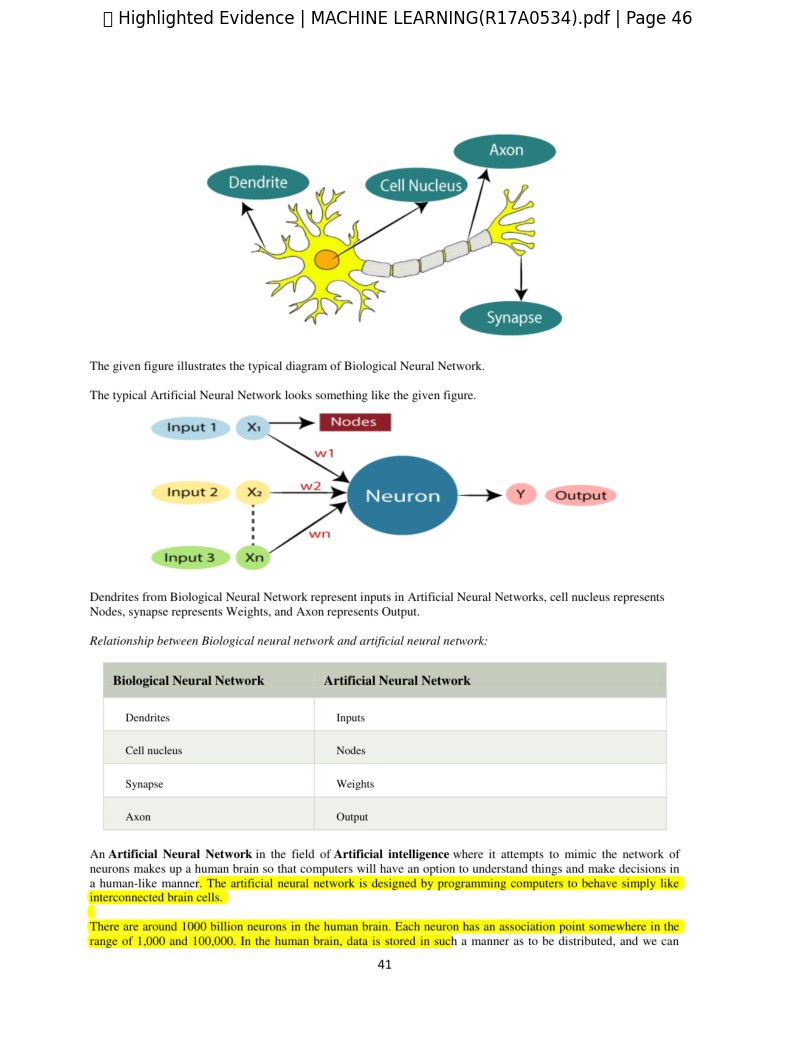


✅ Citation 2: MACHINE LEARNING(R17A0534).pdf | Page 46
🔍 Evidence Preview: 41 The given figure illustrates the typical diagram of Biological Neural Network. The typical Artificial Neural Network looks something like the given figure. Dendrites from Biological Neural Network represent inputs in Artificial Neural Networks, ce ...



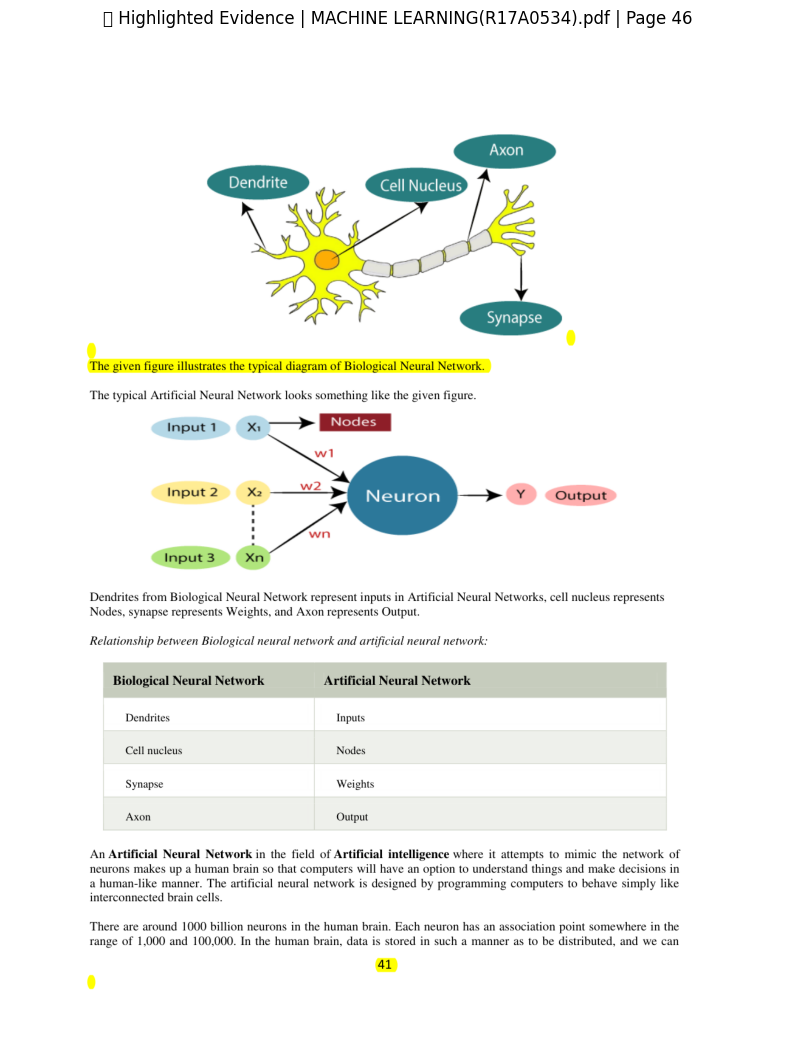

'Machine learning is programming computers to optimize a performance criterion using example data or past experience. We have a model defined up to some parameters, and learning is the execution of a computer program to optimize the parameters of the model using the training data or past experience. It includes various algorithms such as Linear Regression, Logistic Regression, Support Vector Machine, Multi-class Classification, Decision tree, Bayesian Logic, etc. It includes various algorithms such as Clustering, KNN, and Apriori algorithm.'

In [ ]:
extraordinary_rag_v3("What is Artificial Intelligence?", show_highlight=True, highlight_top_n=2)


In [ ]:
!pip -q install gTTS


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 8.1 MB/s eta 0:00:00


In [ ]:
from gtts import gTTS
from IPython.display import Audio, display
import uuid

def speak(text: str, lang="en"):
    """
    Converts text to voice and plays inside Colab.
    """
    if not text.strip():
        return

    filename = f"voice_{uuid.uuid4().hex}.mp3"
    tts = gTTS(text=text, lang=lang)
    tts.save(filename)
    display(Audio(filename, autoplay=True))


In [ ]:
speak("Hello Bobby, your extraordinary RAG assistant is ready!")


In [ ]:
from google.colab import output
from IPython.display import Javascript
import json

def record_audio():
    display(Javascript("""
    async function recordAudio() {
        const stream = await navigator.mediaDevices.getUserMedia({audio: true});
        const mediaRecorder = new MediaRecorder(stream);
        let chunks = [];

        mediaRecorder.ondataavailable = event => chunks.push(event.data);
        mediaRecorder.start();

        await new Promise(resolve => setTimeout(resolve, 4000)); // 4 sec recording
        mediaRecorder.stop();

        await new Promise(resolve => mediaRecorder.onstop = resolve);

        const blob = new Blob(chunks, { type: 'audio/webm' });
        const arrayBuffer = await blob.arrayBuffer();
        const base64Audio = btoa(String.fromCharCode(...new Uint8Array(arrayBuffer)));

        return base64Audio;
    }

    recordAudio().then(audioData => {
        google.colab.kernel.invokeFunction('notebook.get_audio', [audioData], {});
    });
    """))

audio_data = None

def _get_audio(data):
    global audio_data
    audio_data = data

output.register_callback('notebook.get_audio', _get_audio)


In [ ]:
!pip -q install transformers


In [ ]:
from transformers import pipeline

speech_to_text = pipeline("automatic-speech-recognition", model="openai/whisper-small")
print("✅ Whisper Speech-to-Text Loaded!")


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

generation_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

preprocessor_config.json: 0.00B [00:00, ?B/s]

Device set to use cpu


✅ Whisper Speech-to-Text Loaded!


In [ ]:
import base64
import tempfile

def speech_to_text_colab():
    global audio_data

    # record audio
    record_audio()

    # wait small time
    import time
    time.sleep(5)

    if audio_data is None:
        return None

    # decode audio
    audio_bytes = base64.b64decode(audio_data)
    tmp_file = tempfile.NamedTemporaryFile(delete=False, suffix=".webm")
    tmp_file.write(audio_bytes)
    tmp_file.close()

    # transcribe
    text = speech_to_text(tmp_file.name)["text"]
    return text


In [ ]:
def voice_chat():
    print("🎤 VOICE CHAT MODE ON ✅")
    print("Speak your question (4 seconds recording each time).")
    print("Type stop in input if you want to exit.\n")

    while True:
        cmd = input("Press Enter to speak OR type 'exit': ").strip().lower()
        if cmd == "exit":
            print("👋 Voice chat ended.")
            break

        print("🎙️ Recording... Speak now!")
        user_query = speech_to_text_colab()

        if user_query is None:
            print("❌ Could not capture voice. Try again.")
            continue

        print(f"\n🧠 You said: {user_query}")

        # Run RAG Answer (with dashboard + highlight)
        answer = extraordinary_rag_v3(
            user_query,
            show_dashboard=True,
            show_highlight=False,   # set True if you want PDF highlight each time
            highlight_top_n=1
        )

        # Speak response
        print("\n🔊 Speaking Answer...")
        speak(answer)


In [ ]:
voice_chat()


🎤 VOICE CHAT MODE ON ✅
Speak your question (4 seconds recording each time).
Type stop in input if you want to exit.

Press Enter to speak OR type 'exit': speak
🎙️ Recording... Speak now!


<IPython.core.display.Javascript object>

❌ Could not capture voice. Try again.


KeyboardInterrupt: Interrupted by user